In [22]:
#the import packages
import requests
import pandas as pd
from pandas import json_normalize
import requests
import os
from pathlib import Path
from datetime import datetime, timezone,timedelta

import json
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
def loadDataFromFile(file_name):
    script_dir = Path().resolve().parent

    data_folder = script_dir / 'dataAnalysis and machine learning'/'data'
    print(data_folder)
    data_folder.mkdir(exist_ok=True)
    
    file_path = data_folder / (file_name + ".json")
    
    if file_path.exists():
        df = pd.read_json(file_path)
        print(f"Loaded {len(df)} records from {file_path}")
        return df
    else:
        print(f"File {file_path} does not exist.")
        return None    

In [3]:
userInputDataRaw = loadDataFromFile("User:Calibration no source pollutant")
timeSeriesData = loadDataFromFile("Data:Calibration no source pollutant")

/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 12 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/User:Calibration no source pollutant.json
/home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data
Loaded 39638 records from /home/bob/Documents/Diploma project code/Diploma-Project/dataAnalysis and machine learning/data/Data:Calibration no source pollutant.json


In [4]:
userInputDataRaw

,_id,experimentState,timestamp,userInputCategory,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,pollutant-type,quantity-used,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,epoch_ms,timestamp_local
0,{'$oid': '68a0b932a1fbc302e14444b5'},StartingExperiment,{'$date': 1755363634147},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755363634147,2025-08-16 17:00:34.147
1,{'$oid': '68a0b9d5a1fbc302e144468f'},NoSourcePollutantInserted,{'$date': 1755363797903},ExperimentState,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,1755363797903,2025-08-16 17:03:17.903
2,{'$oid': '688801042b6a61abefaee294'},RemovingSourcePollutant,{'$date': 1755377884000},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755377884000,2025-08-16 20:58:04.000
3,{'$oid': '68a1e16fcf51922818e73582'},StartingExperiment,{'$date': 1755439471205},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755439471205,2025-08-17 14:04:31.205
4,{'$oid': '68a1e40420b06e7dc691f360'},NoSourcePollutantInserted,{'$date': 1755440132473},ExperimentState,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,1755440132473,2025-08-17 14:15:32.473
5,{'$oid': '68a1f16320b06e7dc6921bb0'},RemovingSourcePollutant,{'$date': 1755443555956},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755443555956,2025-08-17 15:12:35.956
6,{'$oid': '68a250a7db6a7981de8bad52'},StartingExperiment,{'$date': 1755467943017},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755467943017,2025-08-17 21:59:03.017
7,{'$oid': '68a2513fdb6a7981de8baf21'},InsertingSourcePollutant,{'$date': 1755468095310},ExperimentState,None,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,VOC,30 ml,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,1755468095310,2025-08-17 22:01:35.310
8,{'$oid': '68a25882db6a7981de8bc45d'},RemovingSourcePollutant,{'$date': 1755469954696},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755469954696,2025-08-17 22:32:34.696
9,{'$oid': '68a25d7cdb6a7981de8bd2f5'},StartingExperiment,{'$date': 1755471228737},ExperimentState,None,None,None,NaN,None,None,None,None,None,NaN,NaN,NaN,NaN,None,1755471228737,2025-08-17 22:53:48.737


In [5]:
timeSeriesData

,timestamp,Id=0:BME680:breathVocEquivalent,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
0,2025-08-16 17:00:36,1.094831,NaN,NaN
1,2025-08-16 17:00:37,NaN,NaN,1.884669
2,2025-08-16 17:00:39,1.095380,NaN,NaN
3,2025-08-16 17:00:40,NaN,NaN,1.980727
4,2025-08-16 17:00:42,1.114183,NaN,NaN
...,...,...,...,...
39633,2025-08-17 23:24:54,NaN,5.120193,NaN
39634,2025-08-17 23:24:55,NaN,NaN,4.538580
39635,2025-08-17 23:24:57,NaN,4.807732,NaN
39636,2025-08-17 23:24:57,3.159337,NaN,NaN


In [6]:
timeSeriesData["timestamp"]

0       2025-08-16 17:00:36
1       2025-08-16 17:00:37
2       2025-08-16 17:00:39
3       2025-08-16 17:00:40
4       2025-08-16 17:00:42
                ...        
39633   2025-08-17 23:24:54
39634   2025-08-17 23:24:55
39635   2025-08-17 23:24:57
39636   2025-08-17 23:24:57
39637   2025-08-17 23:24:58
Name: timestamp, Length: 39638, dtype: datetime64[ns]

In [7]:
userInputData = userInputDataRaw.drop(columns=["_id","timestamp","epoch_ms","userInputCategory","pollutant-type","quantity-used"])

In [8]:
userInputData["timestamp_local"] = pd.to_datetime(userInputData["timestamp_local"])  # ensure datetime
userInputData["timestamp_local"] = userInputData["timestamp_local"].dt.floor("s")

In [9]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp_local
0,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-16 17:00:34
1,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-16 17:03:17
2,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-16 20:58:04
3,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 14:04:31
4,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-17 14:15:32
5,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 15:12:35
6,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 21:59:03
7,InsertingSourcePollutant,None,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,2025-08-17 22:01:35
8,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 22:32:34
9,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 22:53:48


In [10]:
userInputDataCompressed = userInputData[userInputData["experimentState"].isin(["NoSourcePollutantInserted","InsertingSourcePollutant"])].copy()


In [11]:
userInputDataCompressed

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp_local
1,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-16 17:03:17
4,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-17 14:15:32
7,InsertingSourcePollutant,None,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,2025-08-17 22:01:35
10,InsertingSourcePollutant,on,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,2025-08-17 22:58:58


In [12]:
userInputDataCompressed.index


Index([1, 4, 7, 10], dtype='int64')

In [13]:
userInputData

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp_local
0,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-16 17:00:34
1,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-16 17:03:17
2,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-16 20:58:04
3,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 14:04:31
4,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-17 14:15:32
5,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 15:12:35
6,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 21:59:03
7,InsertingSourcePollutant,None,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,2025-08-17 22:01:35
8,RemovingSourcePollutant,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 22:32:34
9,StartingExperiment,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,None,2025-08-17 22:53:48


In [14]:
userInputDataCompressed["timestamp_StartingExperiment"] = userInputData["timestamp_local"].shift(1).loc[userInputDataCompressed.index]

In [15]:
userInputDataCompressed["timestamp_EndingExperiment"]= userInputData["timestamp_local"].shift(-1).loc[userInputDataCompressed.index]

In [16]:
userInputDataCompressed

,experimentState,are-doors-opened,are-people-inside,are-windows-opened,front-wall,item-used,notes,room,side-right-wall,back-wall,side-left-wall,are-fans-on,no-source-located,timestamp_local,timestamp_StartingExperiment,timestamp_EndingExperiment
1,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-16 17:03:17,2025-08-16 17:00:34,2025-08-16 20:58:04
4,NoSourcePollutantInserted,on,on,on,NaN,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,NaN,NaN,on,2025-08-17 14:15:32,2025-08-17 14:04:31,2025-08-17 15:12:35
7,InsertingSourcePollutant,None,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,2025-08-17 22:01:35,2025-08-17 21:59:03,2025-08-17 22:32:34
10,InsertingSourcePollutant,on,on,None,1.0,Φαρμακευτικό αλκοόλ 95%,,Σοφίτα-Όλοι οι αισθητήρες μαζί,NaN,NaN,0.5,NaN,None,2025-08-17 22:58:58,2025-08-17 22:53:48,2025-08-17 23:24:58


In [33]:
start =userInputDataCompressed["timestamp_local"].iloc[0]
end=userInputDataCompressed["timestamp_EndingExperiment"].iloc[0]
timestamp = pd.date_range(start=start, end=end, freq="s",name="timestamp")

justTimestamp = pd.DataFrame(timestamp)
justTimestamp["Id=0:BME680:breathVocEquivalent"]  = np.nan
justTimestamp["Id=1:BME680:breathVocEquivalent"]  = np.nan
justTimestamp["Id=2:BME680:breathVocEquivalent"]  = np.nan

justTimestamp

,timestamp,Id=0:BME680:breathVocEquivalent,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
0,2025-08-16 17:03:17,NaN,NaN,NaN
1,2025-08-16 17:03:18,NaN,NaN,NaN
2,2025-08-16 17:03:19,NaN,NaN,NaN
3,2025-08-16 17:03:20,NaN,NaN,NaN
4,2025-08-16 17:03:21,NaN,NaN,NaN
...,...,...,...,...
14083,2025-08-16 20:58:00,NaN,NaN,NaN
14084,2025-08-16 20:58:01,NaN,NaN,NaN
14085,2025-08-16 20:58:02,NaN,NaN,NaN
14086,2025-08-16 20:58:03,NaN,NaN,NaN


In [18]:
timeSeriesDataToGet = timeSeriesData[(timeSeriesData["timestamp"] >= start) & (timeSeriesData["timestamp"] <= end)]
timeSeriesDataToGet

,timestamp,Id=0:BME680:breathVocEquivalent,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
164,2025-08-16 17:03:18,NaN,1.244104,NaN
165,2025-08-16 17:03:18,1.121423,NaN,NaN
166,2025-08-16 17:03:19,NaN,NaN,1.115498
167,2025-08-16 17:03:21,1.136985,NaN,NaN
168,2025-08-16 17:03:21,NaN,1.326080,NaN
...,...,...,...,...
14262,2025-08-16 20:58:00,2.295254,NaN,NaN
14263,2025-08-16 20:58:01,NaN,NaN,1.949698
14264,2025-08-16 20:58:03,NaN,2.340227,NaN
14265,2025-08-16 20:58:03,2.365427,NaN,NaN


In [19]:
experimentDF = justTimestamp.merge(right = timeSeriesDataToGet,how = "left", on ="timestamp")
experimentDF

,timestamp,Id=0:BME680:breathVocEquivalent,Id=1:BME680:breathVocEquivalent,Id=2:BME680:breathVocEquivalent
0,2025-08-16 17:03:17,NaN,NaN,NaN
1,2025-08-16 17:03:18,NaN,1.244104,NaN
2,2025-08-16 17:03:18,1.121423,NaN,NaN
3,2025-08-16 17:03:19,NaN,NaN,1.115498
4,2025-08-16 17:03:20,NaN,NaN,NaN
...,...,...,...,...
18794,2025-08-16 20:58:01,NaN,NaN,1.949698
18795,2025-08-16 20:58:02,NaN,NaN,NaN
18796,2025-08-16 20:58:03,NaN,2.340227,NaN
18797,2025-08-16 20:58:03,2.365427,NaN,NaN


In [23]:
experimentDF.index.dtype



dtype('int64')

In [24]:

# Melt dataframe: keep 'timestamp' fixed, put other columns into "sensor" + "value"
plot_df = experimentDF.melt(
    id_vars=["timestamp"], 
    value_vars=[
        "Id=0:BME680:breathVocEquivalent",
        "Id=1:BME680:breathVocEquivalent",
        "Id=2:BME680:breathVocEquivalent"
    ],
    var_name="Sensor", 
    value_name="VOC"
)

plot_df

,timestamp,Sensor,VOC
0,2025-08-16 17:03:17,Id=0:BME680:breathVocEquivalent,NaN
1,2025-08-16 17:03:18,Id=0:BME680:breathVocEquivalent,NaN
2,2025-08-16 17:03:18,Id=0:BME680:breathVocEquivalent,1.121423
3,2025-08-16 17:03:19,Id=0:BME680:breathVocEquivalent,NaN
4,2025-08-16 17:03:20,Id=0:BME680:breathVocEquivalent,NaN
...,...,...,...
56392,2025-08-16 20:58:01,Id=2:BME680:breathVocEquivalent,1.949698
56393,2025-08-16 20:58:02,Id=2:BME680:breathVocEquivalent,NaN
56394,2025-08-16 20:58:03,Id=2:BME680:breathVocEquivalent,NaN
56395,2025-08-16 20:58:03,Id=2:BME680:breathVocEquivalent,NaN


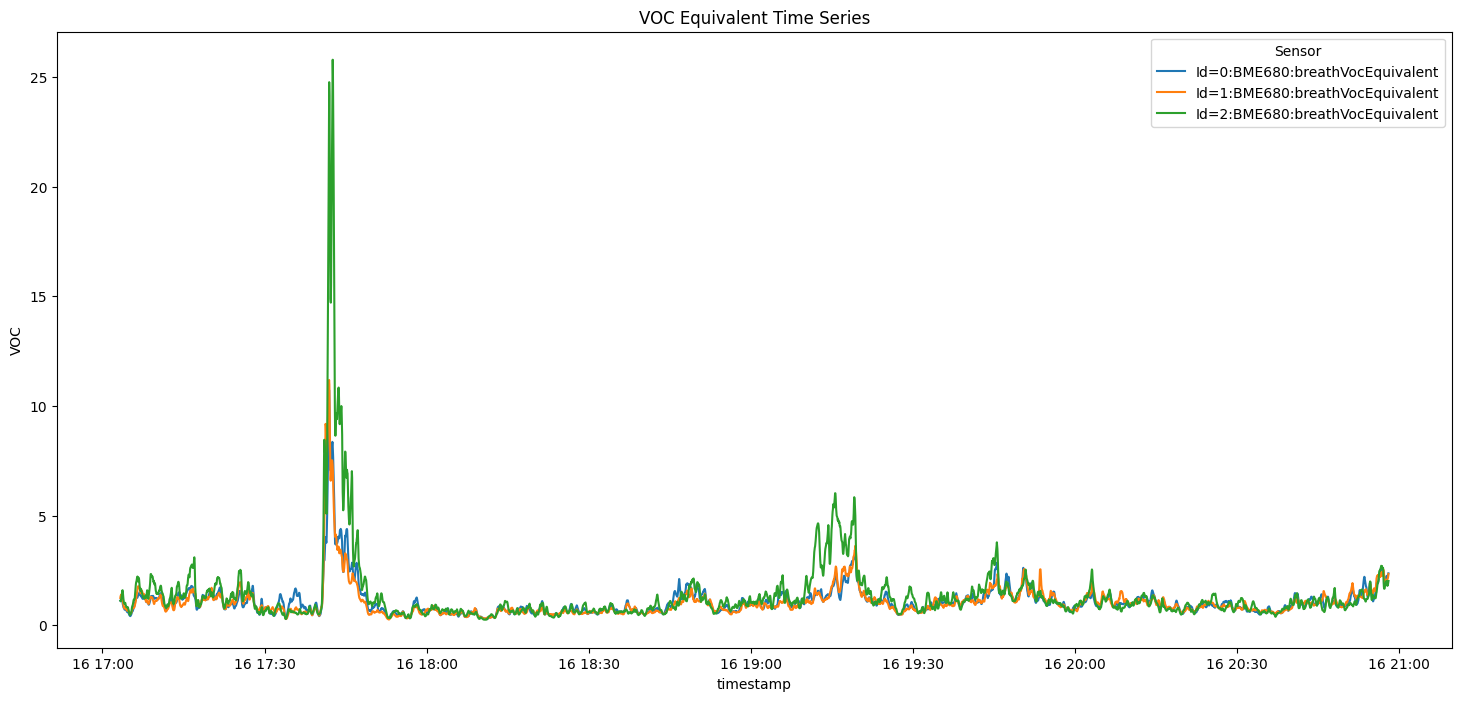

In [32]:
# Plot with seaborn
plt.figure(figsize=(18, 8))
sns.lineplot(data=plot_df, x="timestamp", y="VOC", hue="Sensor")
plt.xticks(rotation=45)
plt.title("VOC Equivalent Time Series")
plt.show()